# 01 — Raw Data Audit

The data-quality gate. Run this **first**, before feature engineering or any analysis: if the raw prices are wrong, everything built on them is wrong too.

This notebook reads the raw ingested parquet (what `ingest.py` writes) and checks:

1. Shape, date range, symbol count
2. Duplicate `(date, symbol)` rows
3. Missing values
4. Price sanity — non-positive prices, `high < low`, close outside the day's range
5. Split/adjustment divergence between raw and adjusted close
6. Trading-day gaps per symbol

Nothing here is destructive — it reports. Fixing issues belongs upstream in ingestion, not here.

In [35]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 14

warnings.filterwarnings("ignore")
pd.set_option("display.max_rows", 120)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

In [36]:
# Ensure the project root is on the import path so `src` can be imported.
PROJECT_ROOT = Path.cwd().resolve()
for parent in (PROJECT_ROOT, *PROJECT_ROOT.parents):
    if (parent / 'src').is_dir():
        PROJECT_ROOT = parent
        break
else:
    raise RuntimeError('Run this notebook from inside the StockForecastRisk repository.')

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.forecast_engine.data.loader import RAW_PRICES_PATH, load_raw_prices
from src.forecast_engine.features.schema import (
    FEATURE_NAMES,
    TARGET_NAMES,
    BENCHMARK_FEATURE_NAMES,
    SCHEMA_VERSION,
)

raw_prices = load_raw_prices()
raw_prices["date"] = pd.to_datetime(raw_prices["date"])

print(f'Loaded {len(raw_prices):,} rows for {raw_prices["symbol"].nunique():,} tickers')
print(f'Source: {RAW_PRICES_PATH}')

display(raw_prices.head())

Loaded 1,943,662 rows for 497 tickers
Source: D:\StockForecastRisk\data\raw\sp500_yfinance_daily.parquet


,date,symbol,security,gics_sector,gics_sub_industry,adj_close,close,high,low,open,volume
0,2010-01-04,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,19.7730,22.3891,22.6252,22.2675,22.4535,"3,815,561.0000"
1,2010-01-05,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,19.5582,22.1459,22.3319,22.0029,22.3248,"4,186,031.0000"
2,2010-01-06,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,19.4887,22.0672,22.1745,22.0029,22.0672,"3,243,779.0000"
3,2010-01-07,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,19.4634,22.0386,22.0458,21.8169,22.0172,"3,095,172.0000"
4,2010-01-08,A,Agilent Technologies,Health Care,Life Sciences Tools & Services,19.4571,22.0315,22.0672,21.7454,21.9170,"3,733,918.0000"


In [37]:
from src.forecast_engine.data.loader import MACRO_FACTORS_PATH, load_macro_factors

macro = load_macro_factors()
macro["date"] = pd.to_datetime(macro["date"])
macro = macro.sort_values("date").reset_index(drop=True)
series_columns = [c for c in macro.columns if c != "date"]

print(f'Loaded {len(macro):,} rows for {len(series_columns):,} macroeconomic series')
print(f'Source: {MACRO_FACTORS_PATH}')

display(macro.head())

Loaded 6,055 rows for 15 macroeconomic series
Source: D:\StockForecastRisk\data\external\macro_daily.parquet


,date,vix,vix_3m,hy_credit_spread,ig_credit_spread,treasury_10y,treasury_2y,fed_funds_rate,vix_term_ratio,yield_curve_slope,vix_change_5d,hy_credit_spread_change_5d,yield_curve_slope_change_5d,vix_change_20d,hy_credit_spread_change_20d,yield_curve_slope_change_20d
0,2010-01-01,NaN,NaN,NaN,NaN,NaN,NaN,0.0500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2010-01-02,NaN,NaN,NaN,NaN,NaN,NaN,0.0500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2010-01-03,NaN,NaN,NaN,NaN,NaN,NaN,0.0500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2010-01-04,20.0400,22.7700,NaN,NaN,3.8500,1.0900,0.1200,0.8801,2.7600,NaN,NaN,NaN,NaN,NaN,NaN
4,2010-01-05,19.3500,22.3900,NaN,NaN,3.7700,1.0100,0.1200,0.8642,2.7600,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
from src.forecast_engine.data.loader import FUNDAMENTALS_PATH, load_fundamentals

fund = load_fundamentals(FUNDAMENTALS_PATH)
fund["filing_date"] = pd.to_datetime(fund["filing_date"])
if "calendardate" in fund.columns:
    fund["calendardate"] = pd.to_datetime(fund["calendardate"])
    
print(f'Loaded {len(fund):,} fundamental records for {fund["symbol"].nunique():,} tickers')
print(f'Source: {FUNDAMENTALS_PATH}')
print("columns:", list(fund.columns))
display(fund.head())

ImportError: cannot import name 'FUNDAMENTALS_PATH' from 'src.forecast_engine.data.loader' (D:\StockForecastRisk\src\forecast_engine\data\loader.py)

In [ ]:
raw_prices = raw_prices.sort_values(["symbol", "date"]).reset_index(drop=True)
print("columns:", list(raw_prices.columns))

columns: ['date', 'symbol', 'security', 'gics_sector', 'gics_sub_industry', 'adj_close', 'close', 'high', 'low', 'open', 'volume']


In [ ]:
print(f"rows       : {len(raw_prices):,}")
print(f"symbols    : {raw_prices['symbol'].nunique()}")
print(f"date range : {raw_prices['date'].min().date()} to {raw_prices['date'].max().date()}")
print(f"sectors    : {raw_prices['gics_sector'].nunique()}")

expected_cols = {"date", "symbol", "open", "high", "low", "close", "adj_close", "volume"}
missing_cols = expected_cols - set(raw_prices.columns)
print(f"\nmissing expected columns: {missing_cols or 'none'}")

rows       : 1,943,662


symbols    : 497
date range : 2010-01-04 to 2026-07-31
sectors    : 11

missing expected columns: none


In [ ]:
feat_dates = set(raw_prices.index.unique())
macro_dates = set(macro.index.unique())
overlap = feat_dates & macro_dates

print(f"feature trading days : {len(feat_dates)}")
print(f"macro days           : {len(macro_dates)}")
print(f"overlapping          : {len(overlap)} ({len(overlap)/len(feat_dates):.1%} of feature days)")
print(f"feature days NOT in macro: {len(feat_dates - macro_dates)}")
print(f"macro days NOT in feature: {len(macro_dates - feat_dates)}")

feature trading days : 1943662
macro days           : 6055
overlapping          : 6055 (0.3% of feature days)
feature days NOT in macro: 1937607
macro days NOT in feature: 0


In [ ]:
dup_mask = raw_prices.duplicated(subset=["date", "symbol"], keep=False)
n_dup = int(dup_mask.sum())

print(f"duplicate (date, symbol) rows: {n_dup}")
if n_dup:
    display(raw_prices[dup_mask].sort_values(["symbol", "date"]).head(20))

duplicate (date, symbol) rows: 0


In [ ]:
na_counts = pd.concat([
    raw_prices.isna().sum().rename("raw_prices"),
    macro.isna().sum().rename("macro")
], axis=1).sum(axis=1)
na_counts = na_counts[na_counts > 0]

if na_counts.empty:
    print("no missing values")
else:
    report = pd.DataFrame({
        "missing": na_counts,
        "missing_pct": (na_counts / len(raw_prices) * 100).round(3),
    })
    display(report)

,missing,missing_pct
adj_close,48.0000,0.0020
close,48.0000,0.0020
high,48.0000,0.0020
low,48.0000,0.0020
open,48.0000,0.0020
volume,84.0000,0.0040
vix,3.0000,0.0000
vix_3m,3.0000,0.0000
hy_credit_spread,"4,960.0000",0.2550
ig_credit_spread,"4,960.0000",0.2550


In [ ]:
checks = {
    "close <= 0": raw_prices["close"] <= 0,
    "adj_close <= 0": raw_prices["adj_close"] <= 0,
    "open <= 0": raw_prices["open"] <= 0,
    "high < low": raw_prices["high"] < raw_prices["low"],
    "close > high": raw_prices["close"] > raw_prices["high"],
    "close < low": raw_prices["close"] < raw_prices["low"],
    "volume <= 0": raw_prices["volume"] <= 0,
}

sanity = pd.Series({name: int(mask.sum()) for name, mask in checks.items()})
display(sanity.to_frame("violations"))

if sanity.sum() == 0:
    print("all price-sanity checks passed")
else:
    print(f"total violations: {sanity.sum():,} -- inspect and fix upstream in ingestion")

,violations
close <= 0,0
adj_close <= 0,0
open <= 0,0
high < low,0
close > high,0
close < low,0
volume <= 0,0


all price-sanity checks passed


In [ ]:
# Show a few example rows for whichever checks tripped, to make them inspectable.
for name, mask in checks.items():
    if mask.any():
        print(f"\n--- {name} ({int(mask.sum())} rows) ---")
        display(raw_prices.loc[mask, ["date", "symbol", "open", "high", "low", "close", "adj_close", "volume"]].head(10))

zero_vol = raw_prices[raw_prices["volume"] <= 0]

# Concentrated in a few tickers, or spread across many?
print(zero_vol["symbol"].value_counts().head(10))

# Concentrated on specific dates? (a shared date = market-wide → data issue)
print(zero_vol["date"].value_counts().head(10))

# At the start of each ticker's history? (→ pre-listing padding)
first_dates = raw_prices.groupby("symbol")["date"].min()
zero_vol["days_from_start"] = (
    zero_vol["date"] - zero_vol["symbol"].map(first_dates)
).dt.days
print(zero_vol["days_from_start"].describe())

# Does the price move on those days? (price change + zero volume = impossible → artifact)
print((zero_vol["close"] != zero_vol["open"]).mean())

Series([], Name: count, dtype: int64)
Series([], Name: count, dtype: int64)
count   0.0000
mean       NaN
std        NaN
min        NaN
25%        NaN
50%        NaN
75%        NaN
max        NaN
Name: days_from_start, dtype: float64
nan


In [ ]:
# Find where SW actually starts trading
sw = raw_prices[raw_prices["symbol"] == "SW"].sort_values("date")
real_start = sw.loc[sw["volume"] > 0, "date"].min()
print(f"SW real trading starts: {real_start.date()}")
print(f"rows before that: {(sw['date'] < real_start).sum()}")

SW real trading starts: NaT
rows before that: 0


In [ ]:
sw = raw_prices[raw_prices["symbol"] == "SW"].sort_values("date").copy()

# How dense is the problem? 355 out of how many SW rows?
print(f"SW rows: {len(sw)}, zero-volume: {(sw['volume'] <= 0).sum()}")

# Does the flat close carry forward from the previous real day?
sw["prev_close"] = sw["close"].shift(1)
flat = sw[sw["volume"] <= 0]
print("close == previous close on zero-vol days:",
      (flat["close"] == flat["prev_close"]).mean())

# Are high/low also flat? (all four OHLC equal = definitely synthetic)
print("OHLC all equal on zero-vol days:",
      ((flat["open"] == flat["close"]) & (flat["high"] == flat["low"])
       & (flat["open"] == flat["high"])).mean())

SW rows: 0, zero-volume: 0
close == previous close on zero-vol days: nan
OHLC all equal on zero-vol days: nan


In [ ]:
# Cumulative dividend adjustment: how far adj_close sits below close.
raw_prices["dividend_gap"] = raw_prices["close"] / raw_prices["adj_close"] - 1

identical_rows = (raw_prices["close"] == raw_prices["adj_close"]).mean()
print(f"rows where close == adj_close exactly: {identical_rows:.2%}")
print("(these are non-dividend payers, or dates after the last payout)\n")

dividend_profile = (
    raw_prices.groupby("symbol")["dividend_gap"]
    .agg(max_gap="max", mean_gap="mean")
    .sort_values("max_gap", ascending=False)
)
print("Largest cumulative dividend adjustment (%, top 15):")
display((dividend_profile.head(15) * 100).round(2))

non_payers = int((dividend_profile["max_gap"].abs() < 1e-9).sum())
print(f"\ntickers with no dividend adjustment at all: {non_payers} of {len(dividend_profile)}")

rows where close == adj_close exactly: 17.50%
(these are non-dividend payers, or dates after the last payout)

Largest cumulative dividend adjustment (%, top 15):


,max_gap,mean_gap
symbol,,
KDP,847.4900,387.4100
WY,379.1400,48.1400
T,227.7800,87.4500
GEN,181.2900,93.0000
MO,175.8300,81.4100
APO,158.2100,44.4800
IRM,155.5000,63.5900
LYB,150.5600,64.9400
DOC,141.0200,61.2400



tickers with no dividend adjustment at all: 88 of 497


In [ ]:
# Data-error tripwire: the raw and adjusted RETURN series should never diverge
# sharply on a single day. Dividend adjustment shifts the level, not one day's
# return by double digits. Anything flagged here is a vendor data problem.
DIVERGENCE_THRESHOLD = 0.10

ordered = raw_prices.sort_values(["symbol", "date"])
raw_return = ordered.groupby("symbol")["close"].pct_change()
adjusted_return = ordered.groupby("symbol")["adj_close"].pct_change()
return_gap = (raw_return - adjusted_return).abs()

flagged = ordered[return_gap > DIVERGENCE_THRESHOLD]

if flagged.empty:
    print(f"No single-day raw/adjusted return divergence above {DIVERGENCE_THRESHOLD:.0%}.")
else:
    print(f"{len(flagged)} rows with suspicious raw/adjusted return divergence:")
    display(flagged[["date", "symbol", "close", "adj_close"]].head(20))

20 rows with suspicious raw/adjusted return divergence:


,date,symbol,close,adj_close
241717,2017-07-05,BKR,37.2500,29.2231
521501,2016-07-05,DHR,71.2766,67.7273
635829,2016-03-01,EQR,68.6200,44.8682
682010,2011-12-21,EXPE,27.8900,25.2518
779965,2016-03-04,GEN,16.6200,7.9494
780950,2020-02-03,GEN,17.1500,14.9268
804395,2012-07-02,GNRC,20.7700,18.2327
804629,2013-06-10,GNRC,36.4500,36.4500
954932,2012-10-18,IRM,31.2200,14.6887
989298,2016-10-31,JCI,40.3200,32.4819


In [ ]:
# Are they simply identical?
identical = (raw_prices["close"] == raw_prices["adj_close"]).mean()
print(f"rows where close == adj_close exactly: {identical:.2%}")

# Check a ticker with a known recent split — NVDA 10:1 on 2024-06-10
nvda = raw_prices[raw_prices["symbol"] == "NVDA"].sort_values("date")
window = nvda[(nvda["date"] >= "2024-06-05") & (nvda["date"] <= "2024-06-15")]
print(window[["date", "close", "adj_close", "volume"]].to_string(index=False))

rows where close == adj_close exactly: 17.50%
      date    close  adj_close           volume
2024-06-05 122.4400   122.2285 528,402,000.0000
2024-06-06 120.9980   120.7890 664,696,000.0000
2024-06-07 120.8880   120.6792 412,386,000.0000
2024-06-10 121.7900   121.5796 313,434,100.0000
2024-06-11 120.9100   120.7110 222,551,200.0000
2024-06-12 125.2000   124.9940 299,595,000.0000
2024-06-13 129.6100   129.3967 260,704,500.0000
2024-06-14 131.8800   131.6630 309,320,400.0000


In [ ]:
records = []
for symbol, group in raw_prices.groupby("symbol"):
    trading_days = group["date"].dt.normalize().nunique()
    calendar_days = len(pd.bdate_range(group["date"].min(), group["date"].max()))
    records.append({
        "symbol": symbol,
        "rows": len(group),
        "business_days_missing": calendar_days - trading_days,
    })

gaps = pd.DataFrame(records).sort_values("business_days_missing", ascending=False)

print(f"business days missing -- median {int(gaps['business_days_missing'].median())}, "
      f"max {gaps['business_days_missing'].max()}")
span_years = (raw_prices["date"].max() - raw_prices["date"].min()).days / 365.25
expected_holidays = span_years * 9.5   # US markets close ~9-10 days a year
print(f"expected from market holidays alone over {span_years:.1f} years: "
      f"~{expected_holidays:.0f} days")
print("A median near that figure is healthy. The concern is a ticker far ABOVE\n"
      "the median, which means genuinely missing history rather than holidays.\n")
display(gaps.head(15))

business days missing -- median 156, max 157
expected from market holidays alone over 16.6 years: ~157 days
A median near that figure is healthy. The concern is a ticker far ABOVE
the median, which means genuinely missing history rather than holidays.



,symbol,rows,business_days_missing
186,FISV,4168,157
0,A,4169,156
482,WMT,4169,156
28,AMT,4169,156
29,AMZN,4169,156
31,AON,4169,156
464,VRSK,4169,156
465,VRSN,4169,156
467,VRTX,4169,156
469,VTR,4169,156


In [ ]:
display(macro[[c for c in macro.columns if c != "date"]].notna().mean().round(3))
print("date range:", macro["date"].min(), "→", macro["date"].max())
display(macro.describe().round(2))

vix                            1.0000
vix_3m                         1.0000
hy_credit_spread               0.1810
ig_credit_spread               0.1810
treasury_10y                   1.0000
treasury_2y                    1.0000
fed_funds_rate                 1.0000
vix_term_ratio                 1.0000
yield_curve_slope              1.0000
vix_change_5d                  0.9990
hy_credit_spread_change_5d     0.1800
yield_curve_slope_change_5d    0.9990
vix_change_20d                 0.9960
hy_credit_spread_change_20d    0.1780
yield_curve_slope_change_20d   0.9960
dtype: float64

date range: 2010-01-01 00:00:00 → 2026-07-30 00:00:00


,date,vix,vix_3m,hy_credit_spread,ig_credit_spread,treasury_10y,treasury_2y,fed_funds_rate,vix_term_ratio,yield_curve_slope,vix_change_5d,hy_credit_spread_change_5d,yield_curve_slope_change_5d,vix_change_20d,hy_credit_spread_change_20d,yield_curve_slope_change_20d
count,6055,"6,052.0000","6,052.0000","1,095.0000","1,095.0000","6,052.0000","6,052.0000","6,055.0000","6,052.0000","6,052.0000","6,047.0000","1,090.0000","6,047.0000","6,032.0000","1,075.0000","6,032.0000"
mean,2018-04-16 00:00:00,18.3600,20.3300,3.1700,0.9100,2.6700,1.7000,1.4900,0.8900,0.9700,-0.0000,-0.0100,-0.0000,-0.0100,-0.0200,-0.0100
min,2010-01-01 00:00:00,9.1400,11.8500,2.5900,0.7300,0.5200,0.0900,0.0400,0.7100,-1.0800,-18.7400,-0.5200,-0.3800,-35.8900,-0.9400,-0.6500
25%,2014-02-22 12:00:00,13.7800,15.9200,2.8400,0.8000,1.8900,0.3700,0.1000,0.8400,0.2700,-1.2900,-0.0800,-0.0400,-2.3900,-0.1700,-0.0800
50%,2018-04-16 00:00:00,16.7000,19.0600,3.1000,0.8800,2.5200,0.9000,0.3700,0.8800,0.8700,-0.1300,-0.0200,-0.0100,-0.2300,-0.0400,-0.0100
75%,2022-06-07 12:00:00,20.9700,22.8000,3.3600,0.9800,3.4900,2.9100,2.4000,0.9300,1.6400,1.1100,0.0500,0.0300,1.8400,0.1000,0.0600
max,2026-07-30 00:00:00,82.6900,72.9800,4.6100,1.3300,4.9800,5.1900,5.3300,1.3400,2.9100,33.5300,1.1900,0.5900,58.3900,1.3800,0.6200
std,NaN,6.7400,6.0200,0.4400,0.1500,1.0400,1.5700,1.8300,0.0700,0.9400,3.0700,0.1400,0.0700,5.2100,0.2700,0.1200


In [ ]:
# Coverage, and where the gaps sit relative to the first valid value.
rows = []
for column in series_columns:
    s = macro[column]
    first_valid = s.first_valid_index()
    gaps_after = int(s.loc[first_valid:].isna().sum()) if first_valid is not None else len(s)
    rows.append({
            "series": column,
            "coverage": s.notna().mean(),
            "first_valid": macro["date"].iloc[first_valid].date() if first_valid is not None else None,
            "gaps_after_first": gaps_after,
        })
coverage = pd.DataFrame(rows).set_index("series")

print(f"macro date range: {macro['date'].min().date()} -> {macro['date'].max().date()} "
          f"({len(macro):,} rows)")
price_start, price_end = raw_prices['date'].min().date(), raw_prices['date'].max().date()
print(f"price date range: {price_start} -> {price_end}")
if macro['date'].min().date() > price_start:
    print(f"  WARNING: macro starts {(macro['date'].min().date() - price_start).days} days "
              f"after prices -- early rows will have NaN macro values.")
print()
display(coverage.round(3))

# Flag the two failure signatures distinctly.
late_start = coverage[(coverage["coverage"] < 0.95) & (coverage["gaps_after_first"] <= 5)]
scattered = coverage[(coverage["coverage"] < 0.95) & (coverage["gaps_after_first"] > 5)]

if not late_start.empty:
    print("\nLATE START (coverage gap is entirely before the first valid value;")
    print("forward-fill cannot reach it). These series simply do not go back to the")
    print("price start date -- either drop them or accept NaN on the early rows:")
    print("  " + ", ".join(late_start.index))
if not scattered.empty:
    print("\nSCATTERED GAPS remain AFTER the first valid value -- the forward-fill")
    print("in engineer_macro_features did not cover these. Investigate the fetch:")
    print("  " + ", ".join(scattered.index))
if late_start.empty and scattered.empty:
    print("\nAll macro series adequately covered (>=95%).")

macro date range: 2010-01-01 -> 2026-07-30 (6,055 rows)
price date range: 2010-01-04 -> 2026-07-31



,coverage,first_valid,gaps_after_first
series,,,
vix,1.0000,2010-01-04,0
vix_3m,1.0000,2010-01-04,0
hy_credit_spread,0.1810,2023-08-01,0
ig_credit_spread,0.1810,2023-08-01,0
treasury_10y,1.0000,2010-01-04,0
treasury_2y,1.0000,2010-01-04,0
fed_funds_rate,1.0000,2010-01-01,0
vix_term_ratio,1.0000,2010-01-04,0
yield_curve_slope,1.0000,2010-01-04,0



LATE START (coverage gap is entirely before the first valid value;
forward-fill cannot reach it). These series simply do not go back to the
price start date -- either drop them or accept NaN on the early rows:
  hy_credit_spread, ig_credit_spread, hy_credit_spread_change_5d, hy_credit_spread_change_20d


In [ ]:
# Range sanity for the core series, and a spot-check that VIX reflects known stress.
plausible = {
    "vix": (9, 90), "vix_3m": (9, 90),
    "hy_credit_spread": (1, 12), "ig_credit_spread": (0.3, 5),
    "treasury_10y": (0, 8), "treasury_2y": (0, 8),
    "fed_funds_rate": (0, 8),
}
issues = []
for column, (low, high) in plausible.items():
    if column not in macro.columns:
        continue
    valid = macro[column].dropna()
    if valid.empty:
        issues.append(f"{column}: entirely empty")
    elif valid.min() < low or valid.max() > high:
        issues.append(f"{column}: [{valid.min():.2f}, {valid.max():.2f}] outside [{low}, {high}]")
    elif valid.nunique() == 1:
        issues.append(f"{column}: constant at {valid.iloc[0]:.2f} -- likely a dead feed")
print("Range issues:", issues if issues else "none -- all core series within plausible bounds")

# VIX should spike during known stress; if it is flat through 2022 the feed is suspect.
if "vix" in macro.columns:
    vix_2022 = macro.loc[macro["date"].dt.year == 2022, "vix"]
    if not vix_2022.empty:
        print(f"\nVIX in 2022: min {vix_2022.min():.1f}, max {vix_2022.max():.1f} "
                f"(expect a max above ~30 from the 2022 selloff)")

Range issues: none -- all core series within plausible bounds

VIX in 2022: min 16.6, max 36.5 (expect a max above ~30 from the 2022 selloff)


## Short interest (FINRA consolidated)

The first **non-price** feature: biweekly consolidated short interest from FINRA,
merged point-in-time on the dissemination date. This audit answers the questions
that decide whether the feature is usable and how far back it reaches:

1. **Coverage vs the 497-ticker universe** — how many names matched, and which
   are missing (usually share-class symbol-format mismatches, e.g. BRK.B vs BRK-B).
2. **Date floor** — FINRA's API history does not reach the 2010 price start; the
   gap before its first date is the same partial-history situation as the credit
   spreads, and is handled the same way (scope short-interest experiments to the
   covered window, don't let a tree read the NaN block as a date proxy).
3. **Biweekly cadence** — ~2 settlement dates a month, no unexplained gaps.
4. **PIT integrity** — dissemination_date is always after settlement_date, by the
   expected ~8 business days. This is the leakage guard.
5. **Feature sanity** — distributions and null rates on the engineered columns.

In [ ]:
from src.forecast_engine.data.loader import SHORT_INTEREST_PATH, load_short_interest

short = load_short_interest()
if short.empty:
    print("No short-interest file found at", SHORT_INTEREST_PATH)
    print("Run short_interest.run_short_interest_api_ingest(...) first.")
else:
    short["settlement_date"] = pd.to_datetime(short["settlement_date"])
    short["dissemination_date"] = pd.to_datetime(short["dissemination_date"])
    print(f'Loaded {len(short):,} records for {short["symbol"].nunique():,} tickers')
    print(f'Source: {SHORT_INTEREST_PATH}')
    display(short.head())

Loaded 3,881,765 records for 48,619 tickers
Source: D:\StockForecastRisk\data\external\short_interest.parquet


,symbol,settlement_date,short_interest,avg_daily_volume,days_to_cover,dissemination_date,short_interest_change,days_to_cover_change
0,A,2017-12-29,4197300,1234014,3.4000,2018-01-10,NaN,NaN
1,A,2018-01-12,5137321,1867541,2.7500,2018-01-24,0.2240,-0.6500
2,A,2018-01-31,5357450,1814702,2.9500,2018-02-12,0.0428,0.2000
3,A,2018-02-15,5464884,3291327,1.6600,2018-02-27,0.0201,-1.2900
4,A,2018-02-28,4135308,3337573,1.2400,2018-03-12,-0.2433,-0.4200


In [ ]:
# Coverage vs the price universe. Missing names are usually share-class symbol
# mismatches between FINRA and yfinance (dot vs dash), not truly absent data.
universe = set(raw_prices["symbol"].unique())
have = set(short["symbol"].unique())
matched = universe & have
missing = sorted(universe - have)

print(f"universe tickers      : {len(universe)}")
print(f"matched in short data : {len(matched)} ({len(matched)/len(universe):.1%})")
print(f"missing               : {len(missing)}")
if missing:
    print("  sample missing:", missing[:20])
    # Flag the likely share-class culprits (contain a dot or dash).
    share_class = [s for s in missing if ("." in s or "-" in s)]
    if share_class:
        print(f"  of which look like share classes (dot/dash): {share_class}")
        print("  -> normalise symbols (e.g. '.'<->'-') before merging to recover these.")

universe tickers      : 497
matched in short data : 495 (99.6%)
missing               : 2
  sample missing: ['BF-B', 'BRK-B']
  of which look like share classes (dot/dash): ['BF-B', 'BRK-B']
  -> normalise symbols (e.g. '.'<->'-') before merging to recover these.


In [ ]:
# Date floor: how far back does short interest reach vs the 2010 price start?
# This is the same partial-history check applied to the macro credit spreads.
si_start = short["settlement_date"].min()
si_end = short["settlement_date"].max()
price_start = raw_prices["date"].min()
price_end = raw_prices["date"].max()

print(f"short interest range : {si_start.date()} -> {si_end.date()} "
      f"({short['settlement_date'].nunique()} settlement dates)")
print(f"price panel range    : {price_start.date()} -> {price_end.date()}")

gap_years = (si_start - price_start).days / 365.25
covered_frac = (price_end - si_start).days / (price_end - price_start).days
print()
if si_start > price_start:
    print(f"  Short interest starts {gap_years:.1f} years after the price panel.")
    print(f"  ~{1-covered_frac:.0%} of the panel's history (pre-{si_start.year}) will have")
    print(f"  NaN short-interest features. Scope short-interest experiments to")
    print(f"  {si_start.year}+ -- do NOT forward-fill into the pre-coverage block, and")
    print(f"  do not let a tree read that NaN block as a 'before-{si_start.year}' proxy.")
else:
    print("  Short interest covers the full price history.")

short interest range : 2017-12-29 -> 2026-07-15 (206 settlement dates)
price panel range    : 2010-01-04 -> 2026-07-31

  Short interest starts 8.0 years after the price panel.
  ~48% of the panel's history (pre-2017) will have
  NaN short-interest features. Scope short-interest experiments to
  2017+ -- do NOT forward-fill into the pre-coverage block, and
  do not let a tree read that NaN block as a 'before-2017' proxy.


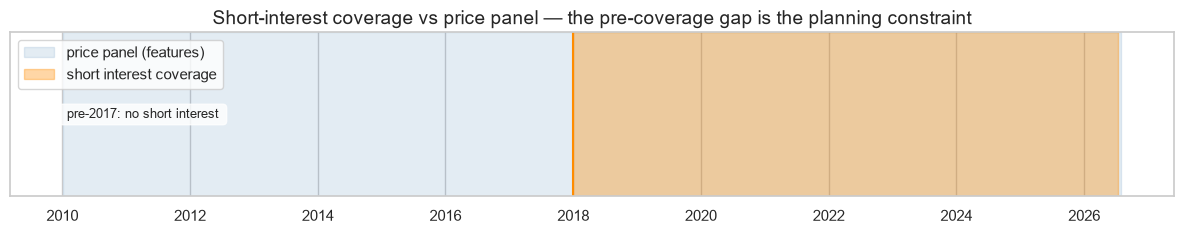

In [ ]:
# Visualise the coverage window against the price panel.
fig, ax = plt.subplots(figsize=(12, 2.5))
ax.axvspan(price_start, price_end, color="steelblue", alpha=0.15, label="price panel (features)")
ax.axvspan(si_start, si_end, color="darkorange", alpha=0.35, label="short interest coverage")
ax.axvline(si_start, color="darkorange", lw=1.5)
ax.set_yticks([])
ax.set_title("Short-interest coverage vs price panel — the pre-coverage gap is the planning constraint")
ax.legend(loc="upper left")
ax.text(price_start, 0.5, f" pre-{si_start.year}: no short interest ",
        va="center", ha="left", fontsize=9,
        bbox=dict(boxstyle="round", fc="white", alpha=0.8))
plt.tight_layout(); plt.show()

settlement dates: 206
spacing (days) -- median 15, min 13, max 19
No gaps beyond 25 days -- cadence is regular (biweekly as expected).


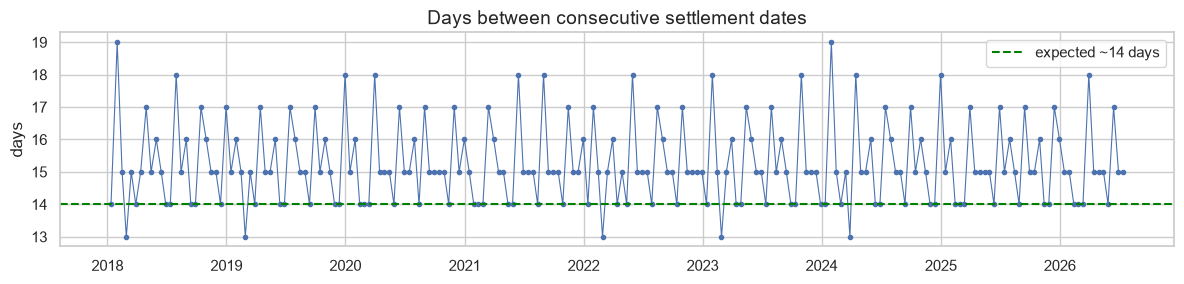

In [ ]:
# Cadence: consolidated short interest is disseminated ~twice a month. Confirm the
# spacing between settlement dates is regular (~14 days), with no large gaps.
settle_dates = pd.Series(sorted(short["settlement_date"].unique()))
spacing = settle_dates.diff().dt.days.dropna()

print(f"settlement dates: {len(settle_dates)}")
print(f"spacing (days) -- median {spacing.median():.0f}, "
      f"min {spacing.min():.0f}, max {spacing.max():.0f}")
big_gaps = spacing[spacing > 25]
if not big_gaps.empty:
    print(f"\n{len(big_gaps)} gap(s) longer than 25 days -- possible missing releases:")
    for idx in big_gaps.index:
        print(f"  {settle_dates[idx-1].date()} -> {settle_dates[idx].date()} "
              f"({int(spacing[idx])} days)")
else:
    print("No gaps beyond 25 days -- cadence is regular (biweekly as expected).")

fig, ax = plt.subplots(figsize=(12, 3))
ax.plot(settle_dates[1:], spacing.values, marker="o", ms=3, lw=0.8)
ax.axhline(14, color="green", ls="--", label="expected ~14 days")
ax.set_title("Days between consecutive settlement dates")
ax.set_ylabel("days"); ax.legend()
plt.tight_layout(); plt.show()

dissemination lag (business days) -- median 8, min 8, max 8
  OK: every record disseminated strictly after settlement (no leakage).


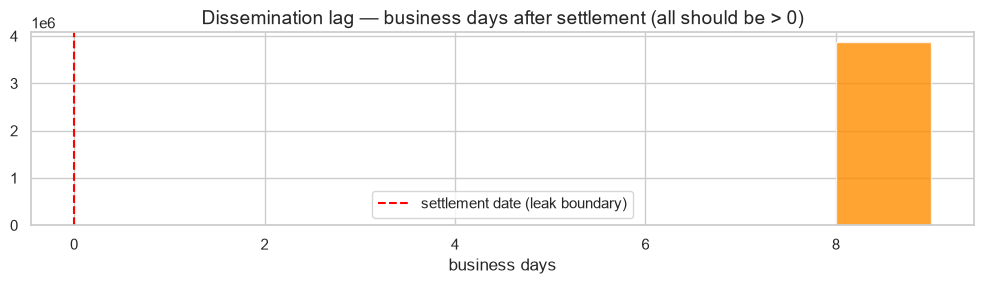

In [ ]:
# PIT integrity: dissemination must ALWAYS be after settlement (the leakage guard),
# by roughly 8 business days. A record disseminated on/before its settlement date
# would be a leak.
lag_bdays = np.busday_count(
    short["settlement_date"].values.astype("datetime64[D]"),
    short["dissemination_date"].values.astype("datetime64[D]"),
)
n_leak = int((lag_bdays <= 0).sum())

print(f"dissemination lag (business days) -- median {np.median(lag_bdays):.0f}, "
      f"min {lag_bdays.min()}, max {lag_bdays.max()}")
if n_leak:
    print(f"  LEAK: {n_leak} records disseminated on/before settlement -- must not happen.")
else:
    print("  OK: every record disseminated strictly after settlement (no leakage).")

fig, ax = plt.subplots(figsize=(10, 3))
ax.hist(lag_bdays, bins=range(int(lag_bdays.min()), int(lag_bdays.max())+2),
        color="darkorange", alpha=0.8)
ax.axvline(0, color="red", ls="--", label="settlement date (leak boundary)")
ax.set_title("Dissemination lag — business days after settlement (all should be > 0)")
ax.set_xlabel("business days"); ax.legend()
plt.tight_layout(); plt.show()

null rate per engineered feature:


,null_frac
short_interest,0.0000
short_interest_change,0.0126
days_to_cover,0.1281
days_to_cover_change,0.1701



(short_interest_change / days_to_cover_change are NaN on each ticker's first
 release by construction -- that is expected, not a data problem.)


,short_interest,short_interest_change,days_to_cover,days_to_cover_change
count,"3,881,765.0000","3,832,748.0000","3,384,672.0000","3,221,559.0000"
mean,"1,907,489.6610",50.0580,"3,900.3150",27.1110
std,"8,354,399.8890","19,397.2130","255,952.2060","293,093.1120"
min,0.0000,-1.0000,0.0000,"-250,280,245.1210"
25%,"2,959.0000",-0.1540,1.0000,-0.3400
50%,"36,053.0000",0.0000,1.5200,0.0000
75%,"676,497.0000",0.1830,5.6200,0.4500
max,"2,131,231,905.0000","35,287,461.4000","250,287,828.5000","250,151,667.2550"


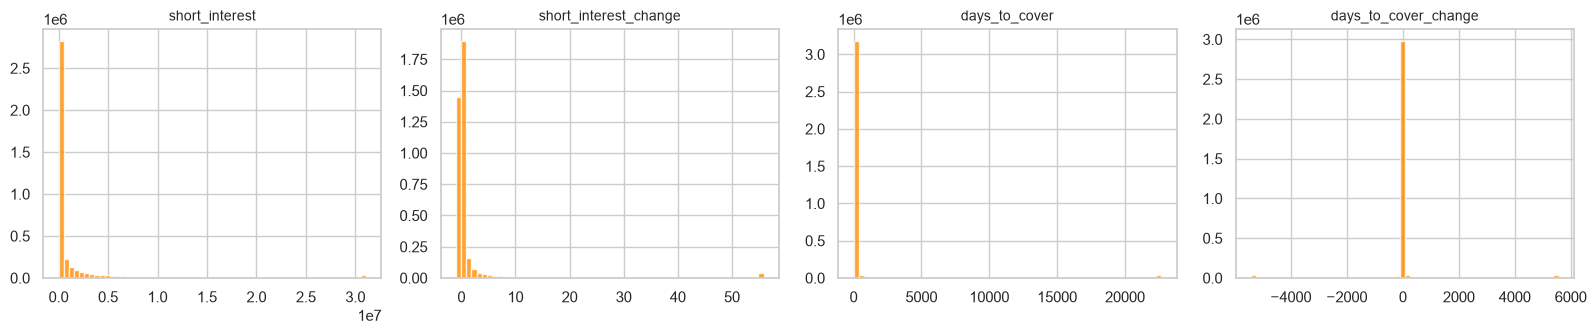

In [ ]:
# Feature sanity: null rates and distributions of the engineered columns.
feat_cols = [c for c in ["short_interest", "short_interest_change",
                         "days_to_cover", "days_to_cover_change"] if c in short.columns]

print("null rate per engineered feature:")
display((short[feat_cols].isna().mean().round(4)).to_frame("null_frac"))
print("\n(short_interest_change / days_to_cover_change are NaN on each ticker's first")
print(" release by construction -- that is expected, not a data problem.)")

display(short[feat_cols].describe().round(3))

# Distributions (clipped to sane quantiles so outliers don't flatten the view).
fig, axes = plt.subplots(1, len(feat_cols), figsize=(4*len(feat_cols), 3.5))
for ax, col in zip(np.atleast_1d(axes), feat_cols):
    v = short[col].dropna()
    lo, hi = v.quantile(0.01), v.quantile(0.99)
    ax.hist(v.clip(lo, hi), bins=60, color="darkorange", alpha=0.8)
    ax.set_title(col, fontsize=10)
plt.tight_layout(); plt.show()

## Fundamentals (SEC EDGAR / Sharadar)

The second non-price source, and the most academically-supported for return
prediction (value/quality factors). Fundamentals carry the same partial-history
and PIT concerns as short interest, plus two of their own that this audit checks:

1. **Coverage vs the 497-ticker universe** — how many names matched via CIK, which
   are missing.
2. **Date floor** — how far back the filings reach vs the 2010 price start.
3. **Filing cadence** — roughly quarterly (~90 days) per ticker, no huge gaps.
4. **PIT integrity — the filing lag.** `filing_date` (when the 10-Q/10-K became
   public) must be strictly *after* `calendardate` (the fiscal period end). If any
   record has filing_date <= period end, the merge would leak the filing lag.
5. **Feature sanity** — growth rates, margins, and ratios in believable ranges (no
   inf from zero-base growth, margins in [-1, 1]-ish, no absurd multiples).

In [ ]:
# Coverage vs the price universe (EDGAR matches via CIK; misses are rare).
if fund is not None:
    universe = set(raw_prices["symbol"].unique())
    have = set(fund["symbol"].unique())
    matched = universe & have
    missing = sorted(universe - have)
    print(f"universe tickers      : {len(universe)}")
    print(f"matched in fundamentals: {len(matched)} ({len(matched)/len(universe):.1%})")
    print(f"missing               : {len(missing)}")
    if missing:
        print("  sample missing:", missing[:20])
        print("  (EDGAR misses come from CIK-mapping gaps or names with no XBRL filings)")

In [ ]:
# Date floor vs the price panel — same partial-history framing as short interest.
if fund is not None:
    f_start, f_end = fund["filing_date"].min(), fund["filing_date"].max()
    price_start, price_end = raw_prices["date"].min(), raw_prices["date"].max()
    print(f"fundamentals range : {f_start.date()} -> {f_end.date()} "
          f"({fund['filing_date'].nunique()} distinct filing dates)")
    print(f"price panel range  : {price_start.date()} -> {price_end.date()}")
    if f_start > price_start:
        gap_yrs = (f_start - price_start).days / 365.25
        print(f"\n  Fundamentals start {gap_yrs:.1f} years after the price panel; rows before")
        print(f"  {f_start.year} will have NaN fundamental features. Scope fundamentals")
        print(f"  experiments to {f_start.year}+ (XBRL mandatory filing began ~2009, so")
        print(f"  EDGAR coverage is typically good back to ~2010).")

    fig, ax = plt.subplots(figsize=(12, 2.3))
    ax.axvspan(price_start, price_end, color="steelblue", alpha=0.15, label="price panel")
    ax.axvspan(f_start, f_end, color="seagreen", alpha=0.35, label="fundamentals coverage")
    ax.axvline(f_start, color="seagreen", lw=1.5)
    ax.set_yticks([]); ax.set_title("Fundamentals coverage vs price panel")
    ax.legend(loc="upper left")
    plt.tight_layout(); plt.show()

In [ ]:
# PIT integrity — THE fundamentals leakage guard: filing_date must be AFTER the
# fiscal period end (calendardate). Filing lag is typically 30-60 days.
if fund is not None and "calendardate" in fund.columns:
    valid = fund.dropna(subset=["filing_date", "calendardate"])
    lag_days = (valid["filing_date"] - valid["calendardate"]).dt.days
    n_leak = int((lag_days <= 0).sum())
    print(f"filing lag (days from period end to filing) -- median {lag_days.median():.0f}, "
          f"min {lag_days.min()}, max {lag_days.max()}")
    if n_leak:
        print(f"  LEAK: {n_leak} records filed on/before their period end -- must not happen.")
    else:
        print("  OK: every filing dated strictly after its fiscal period end (no filing-lag leak).")

    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(lag_days.clip(0, 200), bins=50, color="seagreen", alpha=0.8)
    ax.axvline(0, color="red", ls="--", label="period end (leak boundary)")
    ax.set_title("Filing lag — days from fiscal period end to public filing (all > 0)")
    ax.set_xlabel("days"); ax.legend()
    plt.tight_layout(); plt.show()
elif fund is not None:
    print("No calendardate column -- cannot check filing lag. Confirm the ingest kept it.")

In [ ]:
# Filing cadence — roughly quarterly per ticker.
if fund is not None:
    gaps = (fund.sort_values(["symbol","filing_date"])
              .groupby("symbol")["filing_date"].diff().dt.days.dropna())
    print(f"between-filing gaps (days) -- median {gaps.median():.0f}, "
          f"p90 {gaps.quantile(0.9):.0f}, max {gaps.max():.0f}")
    print("  (median near ~90 = quarterly. Some ~365 gaps are normal where only")
    print("   annual 10-Ks were tagged for a stretch.)")
    fig, ax = plt.subplots(figsize=(10, 3))
    ax.hist(gaps.clip(0, 400), bins=60, color="seagreen", alpha=0.8)
    for d, lab in [(90,"quarterly"), (365,"annual")]:
        ax.axvline(d, ls="--", alpha=0.6, label=lab)
    ax.set_title("Days between consecutive filings per ticker")
    ax.set_xlabel("days"); ax.legend()
    plt.tight_layout(); plt.show()

In [ ]:
# Feature sanity — growth/margin/ratio distributions and null rates.
if fund is not None:
    feat = [c for c in ["revenue_growth_yoy","earnings_growth_yoy","eps_growth_yoy",
                        "grossmargin","netmargin","roe","roa","debt_to_equity"]
            if c in fund.columns]
    print("null rate per engineered feature:")
    display(fund[feat].isna().mean().round(4).to_frame("null_frac"))

    # Leakage/quality flags: any inf? implausible margins?
    import numpy as np
    inf_cols = [c for c in feat if np.isinf(fund[c].to_numpy(dtype="float64", na_value=np.nan)).any()]
    print("columns containing inf (should be none):", inf_cols or "none")

    display(fund[feat].describe(percentiles=[.01,.5,.99]).round(3))

    n = len(feat)
    fig, axes = plt.subplots(1, n, figsize=(3.2*n, 3.2))
    for ax, c in zip(np.atleast_1d(axes), feat):
        v = fund[c].replace([np.inf,-np.inf], np.nan).dropna()
        lo, hi = v.quantile(0.01), v.quantile(0.99)
        ax.hist(v.clip(lo, hi), bins=50, color="seagreen", alpha=0.8)
        ax.set_title(c, fontsize=9)
    plt.tight_layout(); plt.show()

## Audit summary

Fill in from the checks above:

- **Duplicates:** _____
- **Missing values:** _____
- **Price-sanity violations:** _____ (must be fixed in ingestion before proceeding)
- **Tickers with the largest dividend adjustment:** _____
- **Any single-day raw/adjusted return divergence?** _____ (would indicate a vendor data error)
- **Any symbol with abnormal trading-day gaps:** _____

**Gate:** if there are price-sanity violations, resolve them upstream before running feature engineering. Everything downstream assumes clean OHLCV.

**Short interest (FINRA):**
- **Coverage vs universe:** _____ of 497 matched (missing share classes to normalise: _____)
- **Date floor:** short interest starts _____ — pre-coverage rows will be NaN; scope experiments to that year onward.
- **Cadence:** biweekly, gaps beyond 25 days? _____
- **PIT integrity:** any record disseminated on/before settlement? _____ (must be zero)
- **Feature nulls:** as expected (first-release change NaNs only)? _____

**Fundamentals (EDGAR / Sharadar):**
- **Coverage vs universe:** _____ of 497 matched (CIK-mapping misses: _____)
- **Date floor:** fundamentals start _____ — scope experiments to that year onward.
- **PIT filing lag:** any record filed on/before its period end? _____ (must be zero)
- **Cadence:** quarterly (~90-day median gap)? _____
- **Feature sanity:** any inf, or implausible margins/ratios? _____
